# 🔄 THB Forecast - Feature Engineering Pipeline

**Objective**: แสดงกระบวนการทั้งหมดตั้งแต่ Raw Data → Cleaning → Feature Engineering พร้อมอธิบายแต่ละขั้นตอนและแผนอนาคต

---

## 📋 Table of Contents
1. [Raw Data Ingestion](#1-raw-data-ingestion)
2. [Data Cleaning](#2-data-cleaning)
3. [Calendar Features](#3-calendar-features)
4. [Feature Engineering](#4-feature-engineering)
5. [Feature Importance & Benefits](#5-feature-importance--benefits)
6. [Future Planning](#6-future-planning)

In [13]:
# Setup Python Path
import sys
import os

# Get the directory where this notebook is located
notebook_dir = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else os.getcwd()
# Go up two levels to reach project root (from src/notebook/ to root)
project_root = os.path.abspath(os.path.join(notebook_dir, '..', '..'))

# Add to path if not already there
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Notebook Directory: {notebook_dir}")
print(f"Project Root: {project_root}")
print(f"Python Path Updated!\n")

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.de.utils.db_connector import get_engine

# Plotting Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

Notebook Directory: d:\University\CSS\Data Science & Data Engineer\Project\THB_Forecast\src\notebook
Project Root: d:\University\CSS\Data Science & Data Engineer\Project\THB_Forecast
Python Path Updated!



---

## 1. Raw Data Ingestion 📥

### 🎯 Objective
ดึงข้อมูลดิบจาก **Yahoo Finance** (หรือ API อื่นๆ) และบันทึกลงตาราง `raw_data`

###  Data Sources
| Indicator | Ticker | Description |
|-----------|--------|-------------|
| **THB/USD** | `THB=X` | อัตราแลกเปลี่ยนบาทต่อดอลลาร์ |
| **Gold** | `GC=F` | ราคาทองคำ (Futures) |
| **Oil** | `BZ=F` | ราคาน้ำมัน Brent Crude |
| **Bond Yield** | `^TNX` | ผลตอบแทนพันธบัตรสหรัฐอายุ 10 ปี |
| **DXY** | `DX-Y.NYB` | ดัชนีค่าเงินดอลลาร์ |
| **S&P 500** | `^GSPC` | ดัชนีหุ้นสหรัฐ S&P 500 |
| **SET Index** | `^SET.BK` | ดัชนีหุ้นไทย SET |

In [14]:
# Load Raw Data
engine = get_engine()
df_raw = pd.read_sql("SELECT * FROM raw_data ORDER BY record_date DESC LIMIT 10", engine)

print("📊 Raw Data Sample (Latest 10 rows):")
print("="*80)
display(df_raw)

print("\n📈 Data Statistics:")
print(f"   Total Rows: {pd.read_sql('SELECT COUNT(*) as cnt FROM raw_data', engine)['cnt'][0]:,}")
print(f"   Date Range: {pd.read_sql('SELECT MIN(record_date) as start, MAX(record_date) as end FROM raw_data', engine).iloc[0].to_dict()}")
print(f"   Columns: {df_raw.shape[1]}")

📊 Raw Data Sample (Latest 10 rows):


,record_date,oil_close,dxy_raw,gold_close,thb_usd_close,sp500_raw,set_index_raw,bond_yield_raw
0,2025-11-25,62.86,100.115,4156.1001,NaN,NaN,1265.6801,NaN
1,2025-11-24,63.37,100.140,4091.8999,32.37,6705.1201,1252.7300,4.038
2,2025-11-21,62.56,100.180,4076.7000,32.44,6602.9902,1254.4000,4.063
3,2025-11-20,63.38,100.160,4056.5000,32.44,6538.7598,1281.8101,4.106
4,2025-11-19,63.51,100.230,4077.7000,32.37,6642.1602,1272.1700,4.133
5,2025-11-18,64.89,99.550,4061.3000,32.47,6617.3198,1270.0400,4.123
6,2025-11-17,64.20,99.590,4068.3000,32.38,6672.4102,1280.0699,4.133
7,2025-11-14,64.39,99.270,4087.6001,32.35,6734.1099,1269.2600,4.148
8,2025-11-13,63.01,99.180,4186.8999,32.35,6737.4902,1287.4399,4.112
9,2025-11-12,62.71,99.480,4204.3999,32.36,6850.9199,1284.8101,4.065



📈 Data Statistics:
   Total Rows: 2,582
   Date Range: {'start': datetime.date(2016, 1, 1), 'end': datetime.date(2025, 11, 25)}
   Columns: 8


### 🔍 Raw Data Characteristics

**ปัญหาที่พบใน Raw Data:**
- ❌ **Missing Values**: วันหยุดตลาดไม่มีข้อมูล
- ❌ **Column Names**: ชื่อคอลัมน์มี suffix (`_close`, `_raw`)
- ❌ **Data Types**: บางคอลัมน์อาจเป็น string แทน numeric

**Solution**: ต้องทำ Cleaning ในขั้นตอนถัดไป

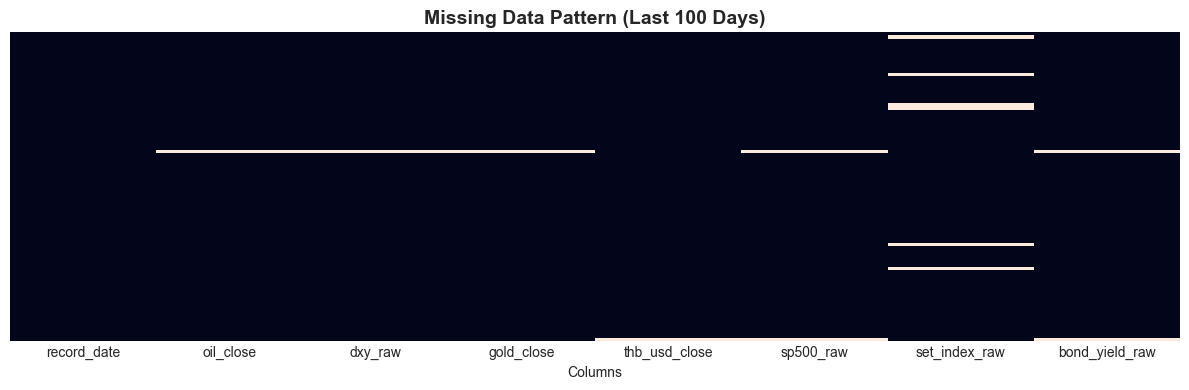


❌ Missing Values Count:
record_date         0
oil_close          91
dxy_raw            91
gold_close         93
thb_usd_close       6
sp500_raw          93
set_index_raw     182
bond_yield_raw     94
dtype: int64


In [15]:
# Visualize Missing Data Pattern
df_raw_all = pd.read_sql("SELECT * FROM raw_data ORDER BY record_date", engine)
df_raw_all['record_date'] = pd.to_datetime(df_raw_all['record_date'])

# Missing Data Heatmap
plt.figure(figsize=(12, 4))
sns.heatmap(df_raw_all.tail(100).isnull(), cbar=False, yticklabels=False)
plt.title('Missing Data Pattern (Last 100 Days)', fontsize=14, fontweight='bold')
plt.xlabel('Columns')
plt.tight_layout()
plt.show()

# Missing Data Count
print("\n❌ Missing Values Count:")
print(df_raw_all.isnull().sum())

---

## 2. Data Cleaning 🧹

### 🎯 Objective
ทำความสะอาดข้อมูล เติมค่าที่หาย และปรับปรุง column names → บันทึกลง `cleaning_data`

### 🔧 Cleaning Steps
1. **Forward Fill**: เติมค่าที่หายด้วยค่าล่าสุด (เหมาะสำหรับ Time Series)
2. **Drop NA**: ลบแถวแรกๆ ที่ยังเป็น NA
3. **Rename Columns**: ตัด suffix ออกให้สวยงาม

In [16]:
# Load Cleaned Data
df_clean = pd.read_sql("SELECT * FROM cleaning_data ORDER BY record_date DESC LIMIT 10", engine)

print("✨ Cleaned Data Sample (Latest 10 rows):")
print("="*80)
display(df_clean)

# Compare with Raw Data
print("\n📊 Comparison:")
print(f"   Raw Data Columns: {df_raw.columns.tolist()}")
print(f"   Cleaned Data Columns: {df_clean.columns.tolist()}")

✨ Cleaned Data Sample (Latest 10 rows):


,record_date,oil,dxy,gold,thb_usd,sp500,set_index,bond_yield
0,2025-11-25,62.86,100.115,4156.1001,32.37,6705.1201,1265.6801,4.038
1,2025-11-24,63.37,100.140,4091.8999,32.37,6705.1201,1252.7300,4.038
2,2025-11-21,62.56,100.180,4076.7000,32.44,6602.9902,1254.4000,4.063
3,2025-11-20,63.38,100.160,4056.5000,32.44,6538.7598,1281.8101,4.106
4,2025-11-19,63.51,100.230,4077.7000,32.37,6642.1602,1272.1700,4.133
5,2025-11-18,64.89,99.550,4061.3000,32.47,6617.3198,1270.0400,4.123
6,2025-11-17,64.20,99.590,4068.3000,32.38,6672.4102,1280.0699,4.133
7,2025-11-14,64.39,99.270,4087.6001,32.35,6734.1099,1269.2600,4.148
8,2025-11-13,63.01,99.180,4186.8999,32.35,6737.4902,1287.4399,4.112
9,2025-11-12,62.71,99.480,4204.3999,32.36,6850.9199,1284.8101,4.065



📊 Comparison:
   Raw Data Columns: ['record_date', 'oil_close', 'dxy_raw', 'gold_close', 'thb_usd_close', 'sp500_raw', 'set_index_raw', 'bond_yield_raw']
   Cleaned Data Columns: ['record_date', 'oil', 'dxy', 'gold', 'thb_usd', 'sp500', 'set_index', 'bond_yield']


### ✅ Cleaning Results

**Before vs After:**
- ✅ No missing values
- ✅ Clean column names (`thb_usd`, `gold`, `oil`, etc.)
- ✅ Proper data types

In [17]:
# Verify No Missing Data
df_clean_all = pd.read_sql("SELECT * FROM cleaning_data ORDER BY record_date", engine)

print("✅ Missing Values After Cleaning:")
print(df_clean_all.isnull().sum())
print(f"\n Total Missing: {df_clean_all.isnull().sum().sum()}")

✅ Missing Values After Cleaning:
record_date    0
oil            0
dxy            0
gold           0
thb_usd        0
sp500          0
set_index      0
bond_yield     0
dtype: int64

 Total Missing: 0


---

## 3. Calendar Features 📅

### 🎯 Objective
สร้าง features จากวันที่ เพื่อให้โมเดลเข้าใจ **temporal patterns** เช่น วันในสัปดาห์ เดือน วันหยุด

### 📋 Calendar Features Created
| Feature | Description | Example | Benefits |
|---------|-------------|---------|----------|
| `day_of_week` | วันในสัปดาห์ (0-6) | 0=Monday | จับ weekly patterns |
| `month` | เดือน (1-12) | 1=January | จับ seasonal patterns |
| `day_of_month` | วันที่ในเดือน (1-31) | 15 | จับ monthly patterns |
| `is_holiday_th` | วันหยุดไทย | 0 or 1 | ตลาดสงบในวันหยุด |
| `is_holiday_us` | วันหยุดสหรัฐ | 0 or 1 | ผลกระทบต่อตลาดโลก |
| `is_weekend` | วันเสาร์-อาทิตย์ | 0 or 1 | ตลาดปิด |

In [18]:
# Load Calendar Data
df_calendar = pd.read_sql("SELECT * FROM calendar_date WHERE year >= 2024 ORDER BY record_date DESC LIMIT 10", engine)

print("📅 Calendar Features Sample:")
print("="*80)
display(df_calendar)

# Holiday Statistics
df_cal_all = pd.read_sql("SELECT * FROM calendar_date WHERE year >= 2024", engine)
print("\n📊 Calendar Statistics (2024):")
print(f"   Total Days: {len(df_cal_all)}")
print(f"   Thai Holidays: {df_cal_all['is_holiday_th'].sum()}")
print(f"   US Holidays: {df_cal_all['is_holiday_us'].sum()}")
print(f"   Weekends: {df_cal_all['is_weekend'].sum()}")

📅 Calendar Features Sample:


,record_date,day_of_week,month,day_of_month,year,is_holiday_th,is_holiday_us,is_weekend
0,2030-12-31,1,12,31,2030,1,0,0
1,2030-12-30,0,12,30,2030,0,0,0
2,2030-12-29,6,12,29,2030,0,0,1
3,2030-12-28,5,12,28,2030,0,0,1
4,2030-12-27,4,12,27,2030,0,0,0
5,2030-12-26,3,12,26,2030,0,0,0
6,2030-12-25,2,12,25,2030,0,1,0
7,2030-12-24,1,12,24,2030,0,0,0
8,2030-12-23,0,12,23,2030,0,0,0
9,2030-12-22,6,12,22,2030,0,0,1



📊 Calendar Statistics (2024):
   Total Days: 2557
   Thai Holidays: 182
   US Holidays: 84
   Weekends: 730


### 💡 Why Calendar Features Matter?

1. **Weekly Patterns**: อัตราแลกเปลี่ยนมักมีความผันผวนต่างกันในแต่ละวัน
2. **Monthly Patterns**: บางเดือนอาจมี trend เฉพาะ (เช่น ช่วงปลายปี)
3. **Holiday Effects**: วันหยุดตลาดมักมีปริมาณการซื้อขายน้อย
4. **Seasonal Patterns**: ช่วงเวลาในปีอาจมีผลต่อค่าเงิน

---

## 4. Feature Engineering 🧠

### 🎯 Objective
สร้าง features ที่ช่วยให้โมเดลทำนายได้แม่นยำขึ้น โดยแบ่งเป็น 5 กลุ่ม

### 📊 Feature Categories

In [19]:
# Load Feature Data
df_features = pd.read_sql("SELECT * FROM feature_data ORDER BY record_date DESC LIMIT 10", engine)

print("🧠 Final Feature Data Sample:")
print("="*80)
display(df_features)

print(f"\n📋 Total Features: {len(df_features.columns)}")
print(f"   Columns: {df_features.columns.tolist()}")

🧠 Final Feature Data Sample:


,record_date,oil,dxy,gold,thb_usd,sp500,set_index,bond_yield,day_of_week,month,day_of_month,year,is_holiday_th,is_holiday_us,volatility_5,volatility_20,gold_oil_ratio,bond_dxy_ratio,sma_50,dist_sma20,rsi,macd,pct_change,target_diff,lag_1,lag_7
0,2025-11-25,63.37,100.14,4091.8999,32.37,6705.1201,1252.7300,4.038,1,11,25,2025,0,0,0.0455,0.0810,64.5716,0.0403,32.3747,-0.0001,47.0399,-0.0141,-0.0022,0.00,32.37,32.350
1,2025-11-24,62.56,100.18,4076.7000,32.37,6602.9902,1254.4000,4.063,0,11,24,2025,0,0,0.0430,0.1004,65.1646,0.0406,32.3619,0.0024,50.6359,-0.0111,0.0000,-0.07,32.44,32.350
2,2025-11-21,63.38,100.16,4056.5000,32.44,6538.7598,1281.8101,4.106,4,11,21,2025,0,0,0.0507,0.1309,64.0028,0.0410,32.3473,0.0029,50.6359,-0.0143,0.0022,0.00,32.44,32.360
3,2025-11-20,63.51,100.23,4077.7000,32.44,6642.1602,1272.1700,4.133,3,11,20,2025,0,0,0.0498,0.1511,64.2056,0.0412,32.3337,0.0011,47.1524,-0.0181,-0.0031,0.07,32.37,32.350
4,2025-11-19,64.89,99.55,4061.3000,32.37,6617.3198,1270.0400,4.123,2,11,19,2025,0,0,0.0507,0.1738,62.5875,0.0414,32.3215,0.0046,52.0224,-0.0156,0.0028,-0.10,32.47,32.370
5,2025-11-18,64.20,99.59,4068.3000,32.47,6672.4102,1280.0699,4.133,1,11,18,2025,0,0,0.0130,0.1740,63.3692,0.0415,32.3057,0.0023,47.4902,-0.0223,0.0009,0.09,32.38,32.370
6,2025-11-17,64.39,99.27,4087.6001,32.38,6734.1099,1269.2600,4.148,0,11,17,2025,0,0,0.0089,0.1815,63.4819,0.0418,32.2997,0.0016,45.9085,-0.0215,0.0000,0.03,32.35,32.490
7,2025-11-14,63.01,99.18,4186.8999,32.35,6737.4902,1287.4399,4.112,4,11,14,2025,0,0,0.0100,0.1778,66.4482,0.0415,32.2981,0.0016,45.9085,-0.0170,-0.0003,0.00,32.35,32.560
8,2025-11-13,62.71,99.48,4204.3999,32.35,6850.9199,1284.8101,4.065,3,11,13,2025,0,0,0.0576,0.1736,67.0451,0.0409,32.2965,0.0020,46.3094,-0.0110,0.0003,-0.01,32.36,32.490
9,2025-11-12,65.16,99.46,4106.7998,32.36,6846.6099,1300.4700,4.120,2,11,12,2025,0,0,0.0923,0.1701,63.0264,0.0414,32.2955,0.0017,45.8704,-0.0042,-0.0006,0.01,32.35,32.365



📋 Total Features: 26
   Columns: ['record_date', 'oil', 'dxy', 'gold', 'thb_usd', 'sp500', 'set_index', 'bond_yield', 'day_of_week', 'month', 'day_of_month', 'year', 'is_holiday_th', 'is_holiday_us', 'volatility_5', 'volatility_20', 'gold_oil_ratio', 'bond_dxy_ratio', 'sma_50', 'dist_sma20', 'rsi', 'macd', 'pct_change', 'target_diff', 'lag_1', 'lag_7']


### 📈 Feature Groups Breakdown

#### 1. **Technical Indicators** (6 features)
คำนวณจากราคา THB/USD โดยตรง

| Feature | Formula | Benefits |
|---------|---------|----------|
| `rsi` | Relative Strength Index | บ่งชี้ overbought/oversold |
| `macd` | Moving Average Convergence Divergence | บ่งชี้ momentum |
| `sma_50` | 50-day Simple Moving Average | เส้น trend ระยะกลาง |
| `dist_sma20` | Distance from SMA | ระยะห่างจาก trend |
| `pct_change` | Daily % Change | ความผันผวนรายวัน |
| `target_diff` | Price Difference | Target variable สำหรับ train |

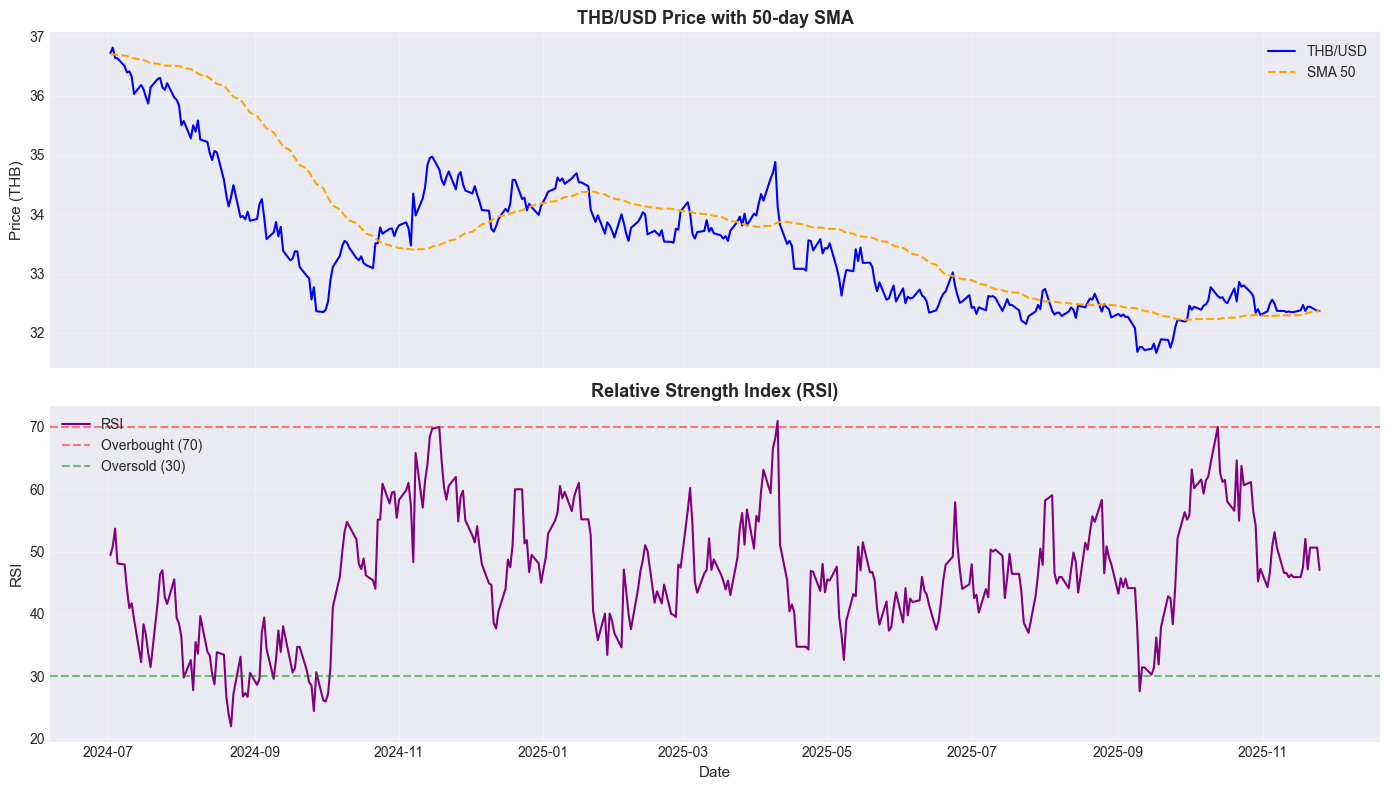

In [20]:
# Visualize Technical Indicators
df_viz = pd.read_sql("SELECT record_date, thb_usd, rsi, sma_50 FROM feature_data ORDER BY record_date DESC LIMIT 365", engine)
df_viz['record_date'] = pd.to_datetime(df_viz['record_date'])
df_viz = df_viz.sort_values('record_date')

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot 1: Price & SMA
axes[0].plot(df_viz['record_date'], df_viz['thb_usd'], label='THB/USD', color='blue', linewidth=1.5)
axes[0].plot(df_viz['record_date'], df_viz['sma_50'], label='SMA 50', color='orange', linestyle='--')
axes[0].set_ylabel('Price (THB)', fontsize=11)
axes[0].set_title('THB/USD Price with 50-day SMA', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: RSI
axes[1].plot(df_viz['record_date'], df_viz['rsi'], label='RSI', color='purple', linewidth=1.5)
axes[1].axhline(y=70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
axes[1].axhline(y=30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
axes[1].set_ylabel('RSI', fontsize=11)
axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_title('Relative Strength Index (RSI)', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### 2. **Volatility Features** (2 features)
วัดความผันผวนของราคา

| Feature | Window | Benefits |
|---------|--------|----------|
| `volatility_5` | 5 days | ความผันผวนระยะสั้น |
| `volatility_20` | 20 days | ความผันผวนระยะยาว |

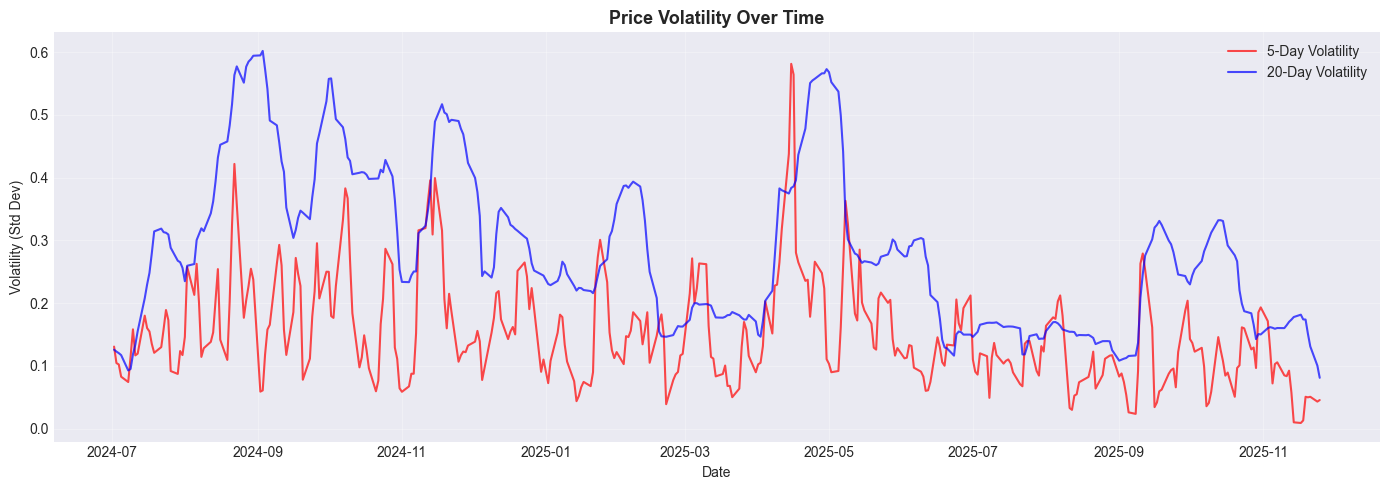

In [21]:
# Volatility Visualization
df_vol = pd.read_sql("SELECT record_date, thb_usd, volatility_5, volatility_20 FROM feature_data ORDER BY record_date DESC LIMIT 365", engine)
df_vol['record_date'] = pd.to_datetime(df_vol['record_date'])
df_vol = df_vol.sort_values('record_date')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_vol['record_date'], df_vol['volatility_5'], label='5-Day Volatility', color='red', alpha=0.7)
ax.plot(df_vol['record_date'], df_vol['volatility_20'], label='20-Day Volatility', color='blue', alpha=0.7)
ax.set_title('Price Volatility Over Time', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Volatility (Std Dev)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 3. **Lag Features** (2 features)
ราคาย้อนหลัง สำหรับจับ temporal dependency

| Feature | Description | Benefits |
|---------|-------------|----------|
| `lag_1` | ราคาเมื่อวาน | ราคา base สำหรับคำนวณ diff |
| `lag_7` | ราคาเมื่อ 7 วันก่อน | จับ weekly pattern |

#### 4. **Relationship Features** (2 features)
อัตราส่วนระหว่าง indicators

| Feature | Formula | Economic Meaning |
|---------|---------|------------------|
| `gold_oil_ratio` | Gold / Oil | Safe-haven vs Risk appetite |
| `bond_dxy_ratio` | Bond Yield / DXY | Interest rate vs Dollar strength |

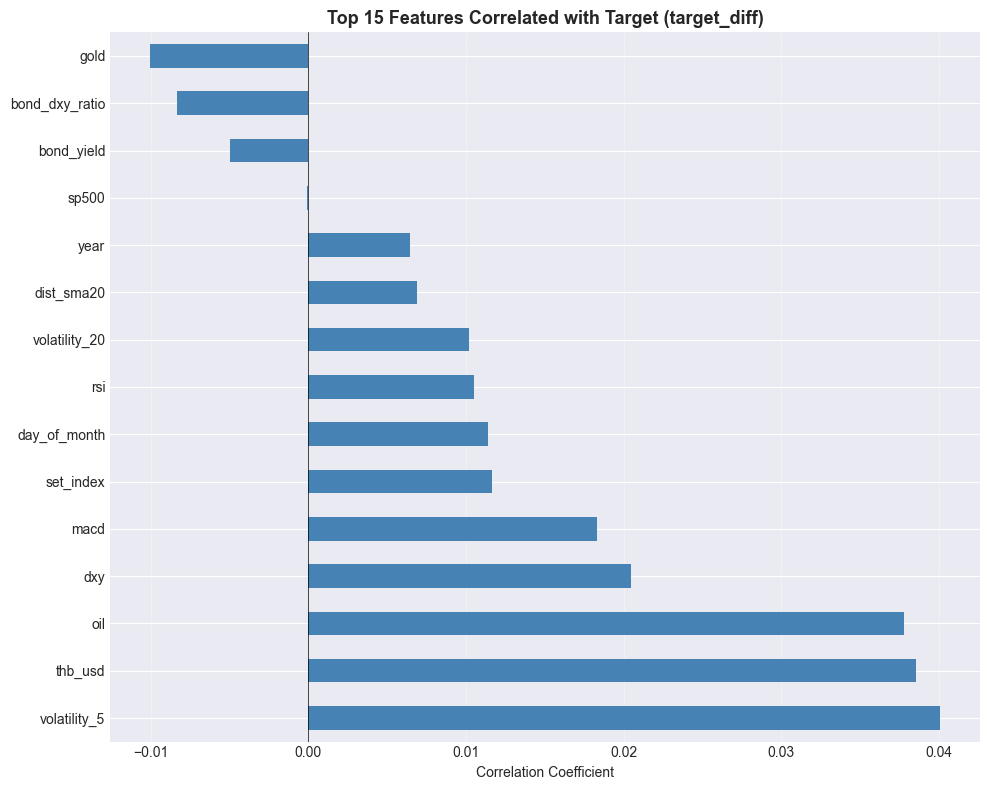


📊 Top 10 Feature Correlations with Target:
volatility_5     0.0401
thb_usd          0.0385
oil              0.0378
dxy              0.0204
macd             0.0183
set_index        0.0116
day_of_month     0.0114
rsi              0.0105
volatility_20    0.0102
dist_sma20       0.0069
Name: target_diff, dtype: float64


In [22]:
# Correlation with THB/USD
df_corr = pd.read_sql("SELECT * FROM feature_data", engine)
numeric_cols = df_corr.select_dtypes(include=[np.number]).columns.tolist()

# Remove date columns
numeric_cols = [col for col in numeric_cols if 'date' not in col.lower()]

# Calculate correlation with target_diff
if 'target_diff' in numeric_cols:
    correlations = df_corr[numeric_cols].corr()['target_diff'].sort_values(ascending=False)
    
    # Plot top 15 correlations
    plt.figure(figsize=(10, 8))
    correlations[1:16].plot(kind='barh', color='steelblue')
    plt.title('Top 15 Features Correlated with Target (target_diff)', fontsize=13, fontweight='bold')
    plt.xlabel('Correlation Coefficient')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.grid(alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Top 10 Feature Correlations with Target:")
    print(correlations[1:11])

#### 5. **Calendar Features** (4 features)
From calendar table (already explained above)

### 🔒 Data Leakage Prevention

**⚠️ Critical Step**: All features ถูก **shift 1 day** เพื่อป้องกัน data leakage

```python
# Example: Shift features by 1 day
features_to_shift = [
    'gold', 'oil', 'bond_yield', 'dxy', 'sp500', 'set_index',
    'rsi', 'macd', 'pct_change', 'sma_50',
    'volatility_5', 'volatility_20',
    'gold_oil_ratio', 'bond_dxy_ratio', 'dist_sma20'
]

for col in features_to_shift:
    df[col] = df[col].shift(1)
```

**Why?** เพื่อให้แน่ใจว่าเราใช้เฉพาะข้อมูลที่มีอยู่ในอดีตเท่านั้น ไม่มีข้อมูลอนาคตรั่วไหล

---

## 5. Feature Importance & Benefits 💡

### 🎯 Why Each Feature Matters?

#### Economic Indicators (7 features)

| Feature | Impact on THB/USD | Example |
|---------|-------------------|----------|
| **Gold** | ทองขึ้น → บาทแข็งค่า | Safe-haven demand |
| **Oil** | น้ำมันขึ้น → บาทอ่อนค่า | Import cost increase |
| **Bond Yield** | ขึ้น → ดอลลาร์แข็งค่า → บาทอ่อน | Interest rate differential |
| **DXY** | ขึ้น → ดอลลาร์แข็งค่า → บาทอ่อน | Direct dollar strength |
| **S&P 500** | ขึ้น → ความเชื่อมั่นสูง | Risk appetite |
| **SET Index** | ขึ้น → เงินไหลเข้าไทย → บาทแข็ง | Capital inflow |
| **Gold/Oil Ratio** | ขึ้น → Safe-haven demand | Risk sentiment |

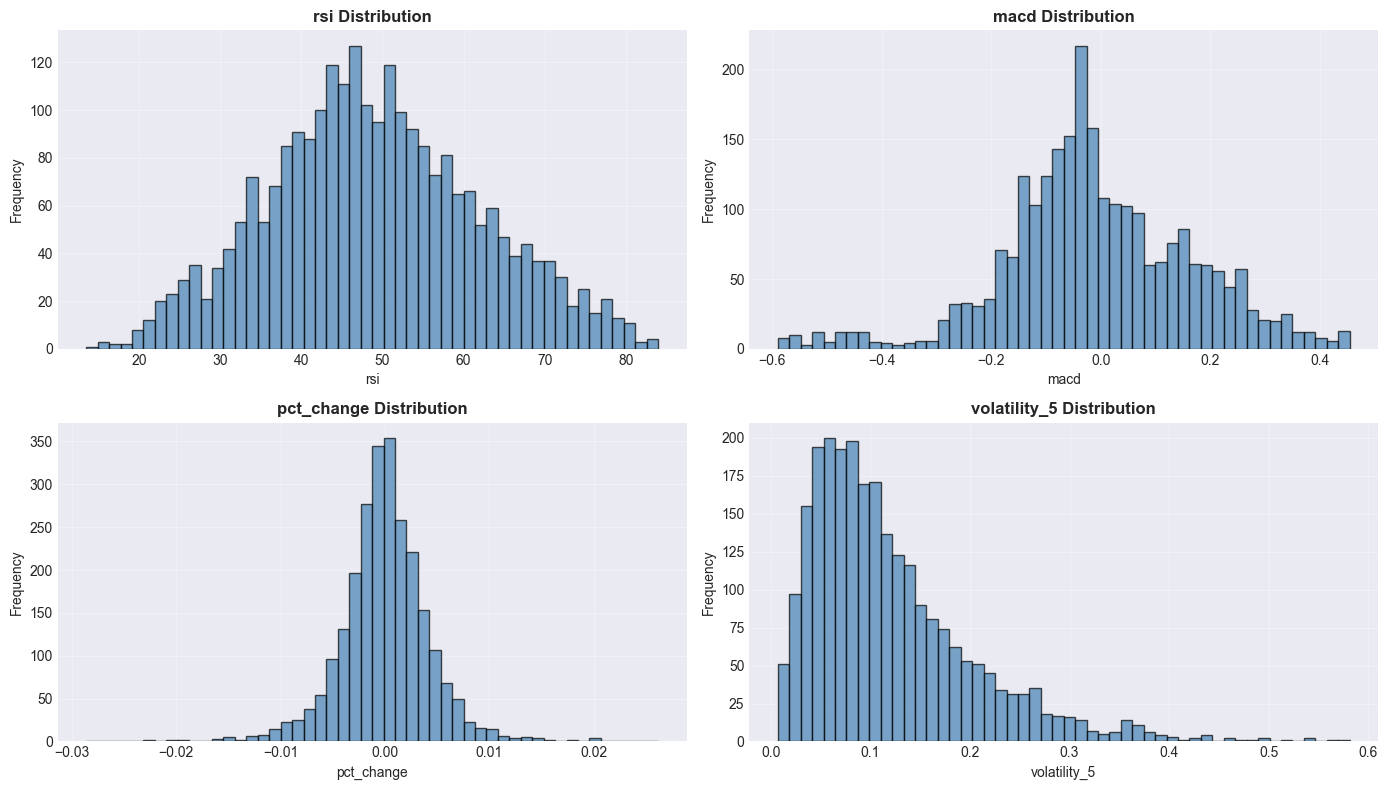

In [23]:
# Feature Distribution
df_dist = pd.read_sql("SELECT rsi, macd, pct_change, volatility_5 FROM feature_data", engine)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
features_to_plot = ['rsi', 'macd', 'pct_change', 'volatility_5']

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx // 2, idx % 2]
    df_dist[feature].hist(bins=50, ax=ax, color='steelblue', alpha=0.7, edgecolor='black')
    ax.set_title(f'{feature} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 🏆 Feature Selection Criteria

Features ถูกเลือกตาม:
1. **Economic Relevance**: มีความเกี่ยวข้องทางเศรษฐศาสตร์
2. **Statistical Significance**: มี correlation กับ target
3. **Availability**: ข้อมูลหาได้ง่าย อัปเดตสม่ำเสมอ
4. **Non-redundancy**: ไม่ซ้ำซ้อนกับ features อื่น

---

## 6. Future Planning 🚀

### 📋 Short-term Improvements (1-3 months)

#### 1. **Additional Economic Indicators**
- ✅ Tourism data (TAT statistics)
- ✅ Trade balance (BOT data)
- ✅ Foreign reserves (BOT data)
- ✅ Interest rate differential

#### 2. **Enhanced Technical Indicators**
- ✅ Bollinger Bands
- ✅ Stochastic Oscillator
- ✅ ATR (Average True Range)
- ✅ Volume indicators

#### 3. **Alternative Data Sources**
- ✅ News sentiment (API: Alpha Vantage, NewsAPI)
- ✅ Social media sentiment (Twitter, Reddit)
- ✅ Google Trends data

---

### 🎯 Long-term Vision (6-12 months)

#### 1. **Real-time Data Pipeline**
```python
# Example architecture
API Sources → Apache Kafka → Stream Processing → Feature Store → Model Inference
```

**Benefits:**
- อัปเดตทันที (< 1 minute latency)
- Scalable for multiple currency pairs
- Event-driven architecture

#### 2. **Feature Store Implementation**
ใช้ **Feature Store** (เช่น Feast, Tecton) สำหรับ:
- Version control features
- Share features across models
- Online/Offline feature serving
- Monitoring feature drift

#### 3. **Advanced Feature Engineering**

**A. Time-based Aggregations**
```python
# Rolling statistics with multiple windows
for window in [7, 14, 30, 60, 90]:
    df[f'mean_{window}d'] = df['thb_usd'].rolling(window).mean()
    df[f'std_{window}d'] = df['thb_usd'].rolling(window).std()
```

**B. Fourier Features**
จับ cyclical patterns
```python
# Weekly cycle
df['sin_weekly'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['cos_weekly'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
```

**C. Interaction Features**
```python
# Feature interactions
df['gold_x_dxy'] = df['gold'] * df['dxy']
df['oil_x_sp500'] = df['oil'] * df['sp500']
```

#### 4. **Multi-Currency Support**
ขยายไปยังสกุลเงินอื่น:
- EUR/USD
- GBP/USD
- JPY/USD
- CNY/USD

**Shared Features:**
- Global indicators (DXY, Gold, Oil)
- US economic data

**Currency-specific Features:**
- Local economic indicators
- Local news sentiment

---

### 🔄 Data Quality Monitoring

**Automated Checks:**
```python
def validate_data_quality(df):
    """
    Data Quality Checks
    """
    checks = {
        'missing_values': df.isnull().sum().sum() == 0,
        'duplicates': df.duplicated().sum() == 0,
        'date_continuity': check_date_gaps(df),
        'value_ranges': check_value_ranges(df),
        'outliers': detect_outliers(df)
    }
    return all(checks.values())
```

**Alerting System:**
- Email/Slack notifications
- Dashboard monitoring
- Auto-retry mechanism

---

### 📊 Feature Importance Tracking

**Monitor feature importance over time:**
```python
# Track feature importance from models
feature_importance_history = {
    'date': [],
    'feature': [],
    'importance': [],
    'model': []
}

# Alert if important features become less important
# → Might indicate data drift or changing market dynamics
```

---

### 🎓 Learning from Model Feedback

**Continuous Improvement Cycle:**
1. **Deploy model** → Make predictions
2. **Collect actual values** → Compare with predictions
3. **Analyze errors** → Where did we go wrong?
4. **Update features** → Add features that capture missed patterns
5. **Retrain model** → Improve performance
6. **Repeat** → Continuous learning

**Example Analysis:**
```python
# Analyze prediction errors
errors_df = pd.DataFrame({
    'date': test_dates,
    'actual': y_true,
    'predicted': y_pred,
    'error': y_true - y_pred
})

# Find patterns in errors
# - Are errors higher on specific days?
# - Are errors higher during high volatility?
# - Are there missing features that could explain errors?
```

---

## 📊 Summary Statistics

In [24]:
# Final Feature Summary
print("="*80)
print("📊 FEATURE ENGINEERING SUMMARY")
print("="*80)

# Count features by category
feature_categories = {
    'Economic Indicators': ['gold', 'oil', 'bond_yield', 'dxy', 'sp500', 'set_index'],
    'Technical Indicators': ['rsi', 'macd', 'sma_50', 'dist_sma20', 'pct_change'],
    'Volatility Features': ['volatility_5', 'volatility_20'],
    'Lag Features': ['lag_1', 'lag_7'],
    'Relationship Features': ['gold_oil_ratio', 'bond_dxy_ratio'],
    'Calendar Features': ['day_of_week', 'month', 'is_holiday_th', 'is_holiday_us']
}

for category, features in feature_categories.items():
    print(f"\n{category}:")
    print(f"   Count: {len(features)}")
    print(f"   Features: {', '.join(features)}")

total_features = sum(len(f) for f in feature_categories.values())
print(f"\n{'='*80}")
print(f"TOTAL FEATURES: {total_features}")
print(f"TARGET VARIABLE: target_diff")
print(f"DATA RANGE: {pd.read_sql('SELECT MIN(record_date) as start, MAX(record_date) as end FROM feature_data', engine).iloc[0]['start']} to {pd.read_sql('SELECT MIN(record_date) as start, MAX(record_date) as end FROM feature_data', engine).iloc[0]['end']}")
print(f"TOTAL ROWS: {pd.read_sql('SELECT COUNT(*) as cnt FROM feature_data', engine)['cnt'][0]:,}")
print("="*80)

📊 FEATURE ENGINEERING SUMMARY

Economic Indicators:
   Count: 6
   Features: gold, oil, bond_yield, dxy, sp500, set_index

Technical Indicators:
   Count: 5
   Features: rsi, macd, sma_50, dist_sma20, pct_change

Volatility Features:
   Count: 2
   Features: volatility_5, volatility_20

Lag Features:
   Count: 2
   Features: lag_1, lag_7

Relationship Features:
   Count: 2
   Features: gold_oil_ratio, bond_dxy_ratio

Calendar Features:
   Count: 4
   Features: day_of_week, month, is_holiday_th, is_holiday_us

TOTAL FEATURES: 21
TARGET VARIABLE: target_diff
DATA RANGE: 2016-03-14 00:00:00 to 2025-11-25 00:00:00
TOTAL ROWS: 2,531


---

## ✅ Conclusion

### 🎯 Key Takeaways

1. **Robust Pipeline**: ข้อมูลผ่านกระบวนการทำความสะอาดและ feature engineering อย่างเป็นระบบ
2. **No Data Leakage**: Features ถูก shift เพื่อป้องกันข้อมูลอนาคตรั่วไหล
3. **Economic Logic**: Features มีความหมายทางเศรษฐศาสตร์ ไม่ใช่แค่ตัวเลข
4. **Scalable**: สามารถขยายไปยังข้อมูลและ features อื่นได้ง่าย
5. **Future-proof**: มีแผนรองรับการพัฒนาในอนาคต

### 🚀 Next Steps

1. ✅ Train models (XGBoost, LSTM, TFT)
2. ✅ Evaluate performance
3. ✅ Deploy best model as API
4. 🔄 Monitor and improve continuously

---

**Created**: 2025-11-25  
**Last Updated**: 2025-11-25  
**Author**: Data Science Team